In [ ]:
# 1. Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical

In [ ]:
# 2. Load Dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Normalize to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
# 3. Build Model
model = Sequential([
    Flatten(input_shape=(28, 28)),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(10, activation='softmax')  # Output layer for multi-class classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# 4. Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# 5. Train Model
history = model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=128,
    verbose=2
)

Epoch 1/15
375/375 - 7s - 19ms/step - accuracy: 0.8776 - loss: 0.3993 - val_accuracy: 0.9545 - val_loss: 0.1503
Epoch 2/15
375/375 - 4s - 10ms/step - accuracy: 0.9447 - loss: 0.1809 - val_accuracy: 0.9642 - val_loss: 0.1185
Epoch 3/15
375/375 - 3s - 9ms/step - accuracy: 0.9558 - loss: 0.1397 - val_accuracy: 0.9704 - val_loss: 0.0993
Epoch 4/15
375/375 - 5s - 13ms/step - accuracy: 0.9634 - loss: 0.1157 - val_accuracy: 0.9724 - val_loss: 0.0934
Epoch 5/15
375/375 - 5s - 14ms/step - accuracy: 0.9689 - loss: 0.1011 - val_accuracy: 0.9734 - val_loss: 0.0906
Epoch 6/15
375/375 - 5s - 12ms/step - accuracy: 0.9705 - loss: 0.0934 - val_accuracy: 0.9760 - val_loss: 0.0814
Epoch 7/15
375/375 - 4s - 10ms/step - accuracy: 0.9749 - loss: 0.0773 - val_accuracy: 0.9751 - val_loss: 0.0841
Epoch 8/15
375/375 - 6s - 15ms/step - accuracy: 0.9765 - loss: 0.0745 - val_accuracy: 0.9759 - val_loss: 0.0811
Epoch 9/15
375/375 - 4s - 12ms/step - accuracy: 0.9774 - loss: 0.0695 - val_accuracy: 0.9764 - val_loss: 

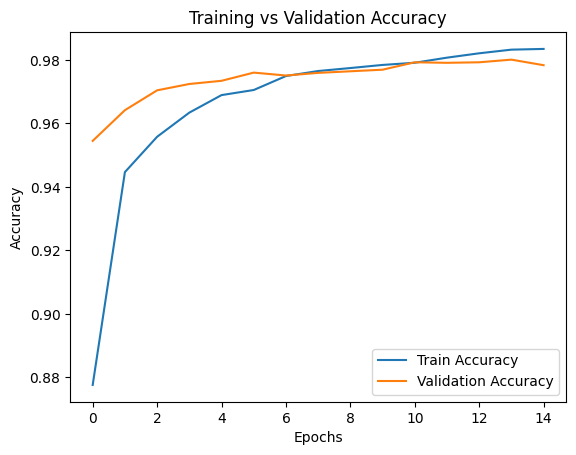

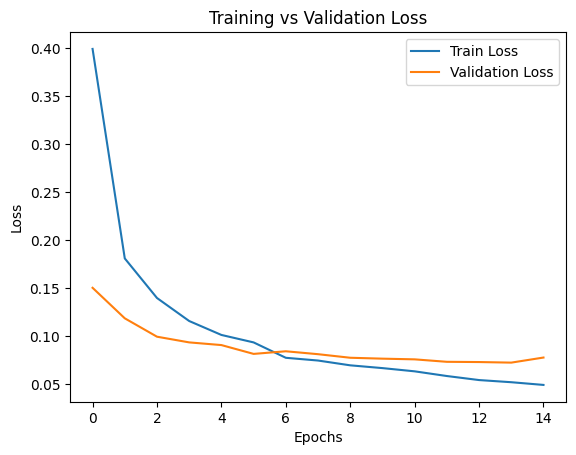

In [ ]:
# 6. Visualization
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [ ]:
# 7. Evaluation
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"✅ Final Test Accuracy: {test_acc:.4f}")

✅ Final Test Accuracy: 0.9804


**Normalization:** Scaling input images to [0,1] speeds up convergence.
**Flatten Layer:** Converts each 28×28 image into a 784-dim vector for Dense layers.
**Batch Normalization:** Stabilizes learning and helps with faster convergence.
**Dropout:** Prevents overfitting by randomly turning off neurons during training.
**Softmax Output Layer:** Ensures outputs represent probabilities for 10 classes.
**Categorical Crossentropy Loss:** Standard for multi-class classification.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


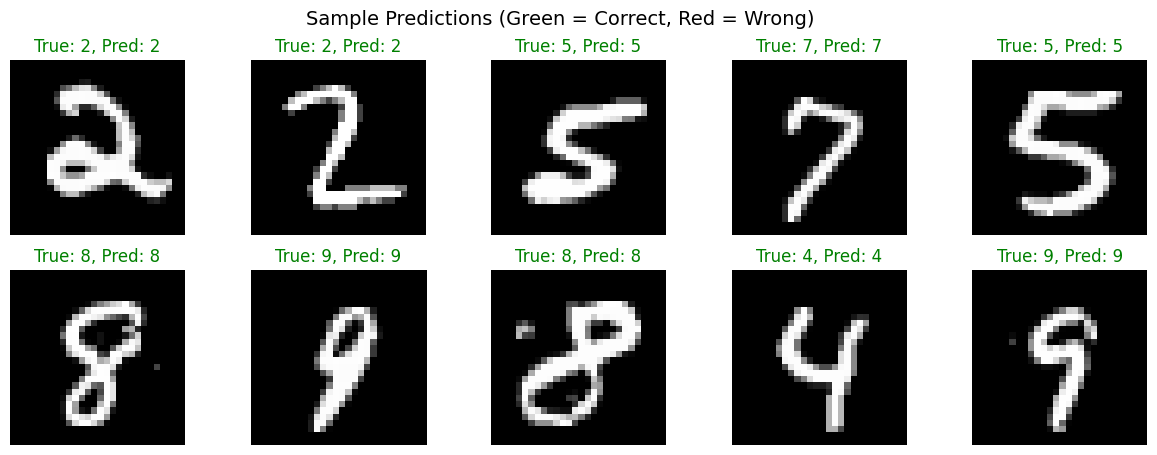

In [ ]:
import random

# 8. Make Predictions
predictions = model.predict(x_test)

# Choose 10 random test samples to display
num_samples = 10
indices = random.sample(range(len(x_test)), num_samples)

plt.figure(figsize=(15, 5))
for i, idx in enumerate(indices):
    img = x_test[idx]
    true_label = np.argmax(y_test[idx])
    pred_label = np.argmax(predictions[idx])

    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {true_label}, Pred: {pred_label}",
              color=("green" if true_label == pred_label else "red"))
    plt.axis("off")

plt.suptitle("Sample Predictions (Green = Correct, Red = Wrong)", fontsize=14)
plt.show()
